 Final model loaded: quantum_alpha_final.pth


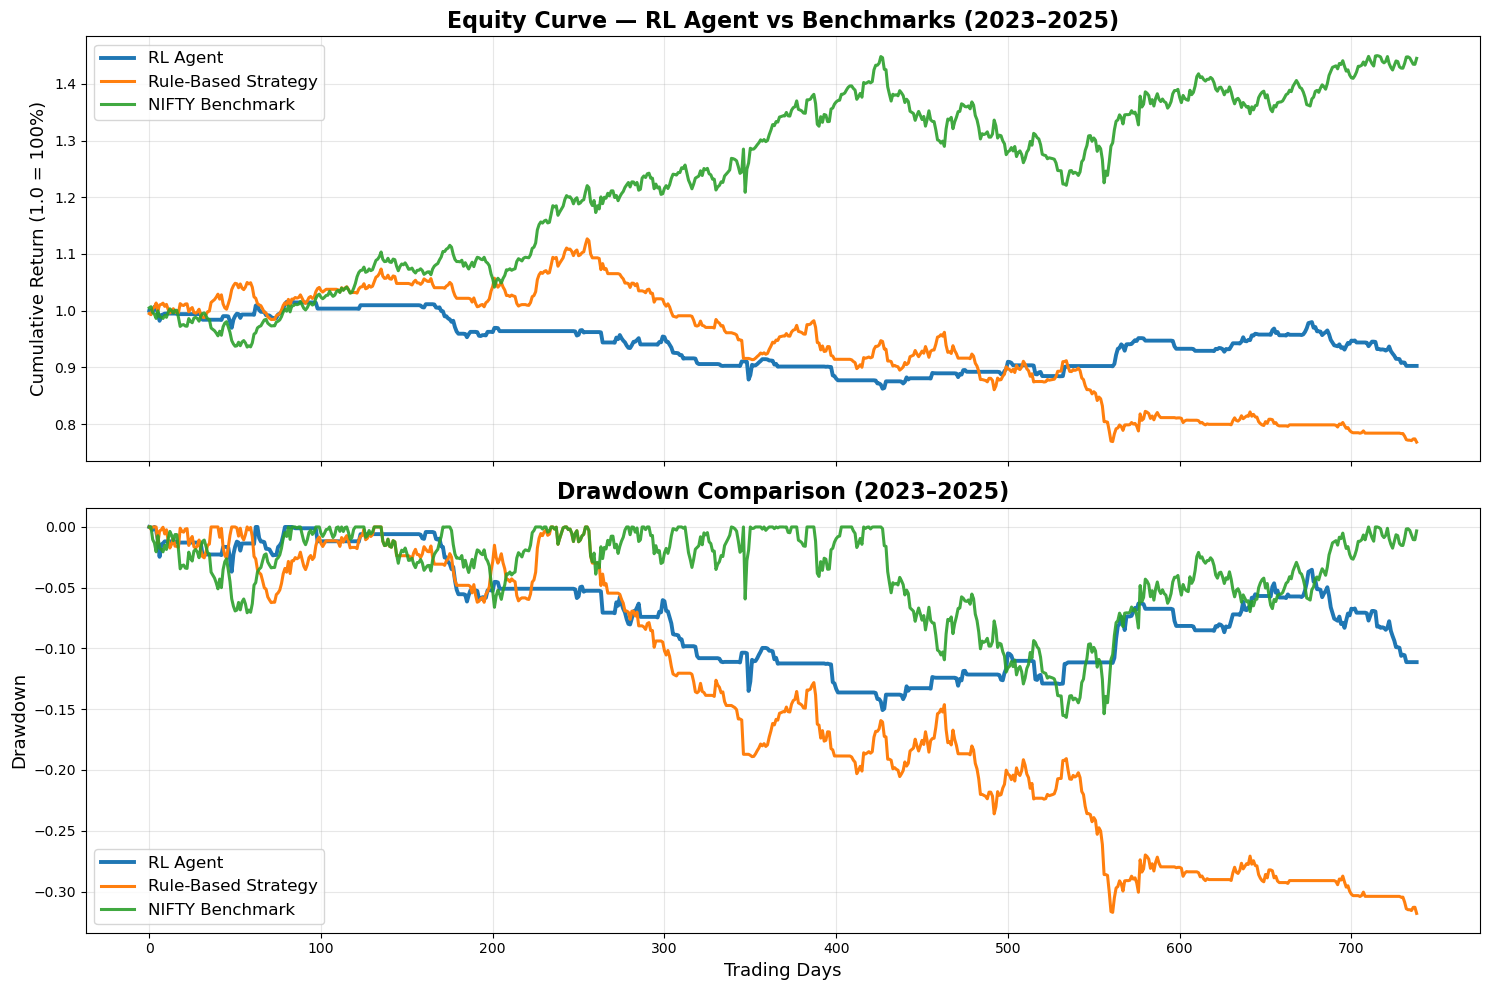


=== SUMMARY METRICS (2023–2025) ===
RL Agent     : CAGR: -3.43% | MaxDD: -15.07%
Rule-Based   : CAGR: -8.59% | MaxDD: -31.80%
NIFTY        : CAGR: +13.37% | MaxDD: -15.67%


In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =============================================
# 1. FINAL DQN MODEL
# =============================================
class DQN(nn.Module):
    def __init__(self, state_size=7, action_size=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_size, 128), nn.ReLU(),
            nn.Linear(128, 128), nn.ReLU(),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.Linear(64, action_size)
        )
    def forward(self, x):
        return self.net(x)

policy_net = DQN().to(device)
policy_net.load_state_dict(torch.load("../models/quantum_alpha_final.pth", map_location=device))
policy_net.eval()
print(" Final model loaded: quantum_alpha_final.pth")

# =============================================
# 2. ENVIRONMENT
# =============================================
class QuantumAlphaEnv:
    def __init__(self, data):
        self.data = data.reset_index(drop=True)
        self.feature_cols = ["mom_20_norm", "vol_signal_norm", "trend_signal_norm",
                             "dd_signal_norm", "vix_signal_norm", "breadth_signal_norm"]
        self.max_steps = len(self.data) - 1
        self.reset()
   
    def reset(self):
        self.current_step = 0
        self.position = 0
        self.balance = 1.0
        return self._get_observation()
   
    def _get_observation(self):
        row = self.data.iloc[self.current_step]
        obs = row[self.feature_cols].values.astype(np.float32)
        return np.append(obs, self.position)
   
    def step(self, action):
        prev_position = self.position
        new_position = {0: 0, 1: 1, 2: -1}[action]
        ret = self.data.iloc[self.current_step]["nifty_ret"]
        cost = abs(new_position - prev_position) * 0.0005
        net_ret = prev_position * ret - cost
        self.balance *= (1 + net_ret)
        self.position = new_position
        self.current_step += 1
        done = self.current_step >= self.max_steps
        return self._get_observation(), net_ret, done, {"net_ret": net_ret, "position": self.position}

# =============================================
# 3. RUN ON FULL TEST PERIOD (2023–2025)
# =============================================
test_data = pd.read_csv("../data/state_dataset.csv", index_col="Date", parse_dates=True)
test_data = test_data.join(pd.read_csv("../data/market_master.csv", index_col="Date", parse_dates=True)[["nifty_ret"]])
test_data = test_data.loc["2023":"2025"]

env = QuantumAlphaEnv(test_data)
state = env.reset()
done = False
equity = 1.0
equity_curve = [1.0]
returns = []
positions = []

while not done:
    with torch.no_grad():
        s = torch.FloatTensor(state).unsqueeze(0).to(device)
        action = policy_net(s).argmax().item()
    next_state, _, done, info = env.step(action)
    equity *= (1 + info["net_ret"])
    equity_curve.append(equity)
    returns.append(info["net_ret"])
    positions.append(info["position"])
    state = next_state

rl_equity = np.array(equity_curve)
rl_returns = np.array(returns)

# Rule-Based & NIFTY
rule = pd.read_csv("../backtesting/market_backtest_v7.csv", index_col=0)
rule.index = pd.to_datetime(rule.index)
rule = rule.loc["2023":"2025"]
rule_equity = (1 + rule["strategy_ret_v2"]).cumprod().values

nifty_equity = (1 + test_data["nifty_ret"]).cumprod().values

# =============================================
# 4. PUBLICATION-QUALITY VISUALISATION
# =============================================
fig, axs = plt.subplots(2, 1, figsize=(15, 10), sharex=True)

# Equity Curve
axs[0].plot(rl_equity, label="RL Agent", linewidth=2.8, color="#1f77b4")
axs[0].plot(rule_equity[:len(rl_equity)], label="Rule-Based Strategy", linewidth=2.2, color="#ff7f0e")
axs[0].plot(nifty_equity[:len(rl_equity)], label="NIFTY Benchmark", linewidth=2.2, color="#2ca02c", alpha=0.9)
axs[0].set_title("Equity Curve — RL Agent vs Benchmarks (2023–2025)", fontsize=16, fontweight='bold')
axs[0].set_ylabel("Cumulative Return (1.0 = 100%)", fontsize=13)
axs[0].legend(fontsize=12)
axs[0].grid(True, alpha=0.3)

# Drawdown Curve
dd_rl   = rl_equity / np.maximum.accumulate(rl_equity) - 1
dd_rule = rule_equity / np.maximum.accumulate(rule_equity) - 1
dd_nifty = nifty_equity / np.maximum.accumulate(nifty_equity) - 1

axs[1].plot(dd_rl, label="RL Agent", linewidth=2.8, color="#1f77b4")
axs[1].plot(dd_rule[:len(dd_rl)], label="Rule-Based Strategy", linewidth=2.2, color="#ff7f0e")
axs[1].plot(dd_nifty[:len(dd_rl)], label="NIFTY Benchmark", linewidth=2.2, color="#2ca02c", alpha=0.9)
axs[1].set_title("Drawdown Comparison (2023–2025)", fontsize=16, fontweight='bold')
axs[1].set_ylabel("Drawdown", fontsize=13)
axs[1].set_xlabel("Trading Days", fontsize=13)
axs[1].legend(fontsize=12)
axs[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================
# 5. SUMMARY METRICS (for paper)
# =============================================
def quick_metrics(equity_arr, returns):
    days = len(returns)
    cagr = equity_arr[-1] ** (252 / days) - 1
    max_dd = (equity_arr / np.maximum.accumulate(equity_arr) - 1).min()
    return f"CAGR: {cagr*100:+.2f}% | MaxDD: {max_dd*100:.2f}%"

print("\n=== SUMMARY METRICS (2023–2025) ===")
print(f"RL Agent     : {quick_metrics(rl_equity, rl_returns)}")
print(f"Rule-Based   : {quick_metrics(rule_equity, rule['strategy_ret_v2'].values)}")
print(f"NIFTY        : {quick_metrics(nifty_equity, test_data['nifty_ret'].values)}")